In [1]:
import matplotlib.pyplot as plt
import numpy as np
from adsp import adspfilter
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
def set_dark_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "#000000",
        "axes.facecolor":   "#000000",
        "axes.edgecolor":   "#FFFFFF",
        "axes.labelcolor":  "#FFFFFF",
        "text.color":       "#FFFFFF",
        "xtick.color":      "#FFFFFF",
        "ytick.color":      "#FFFFFF",
        "grid.color":       "#444444",
        "legend.facecolor": "#000000",
        "legend.edgecolor": "#FFFFFF",
        "savefig.facecolor":"#000000",
        "savefig.edgecolor":"#000000",
    })
set_dark_style()

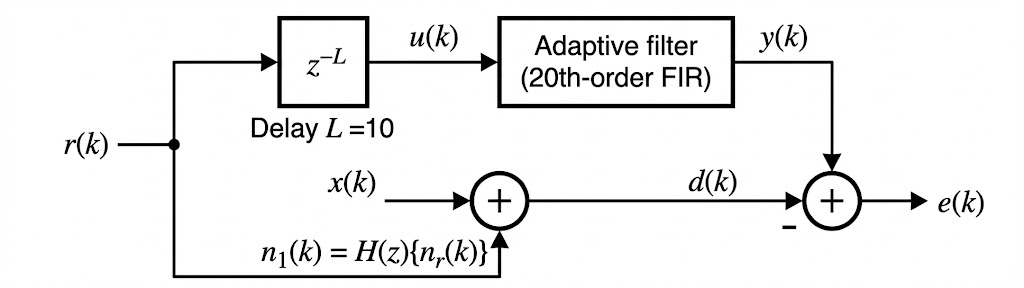
In a signal enhancement problem, the reference signal is $r(k)=\sin(0.2 \pi k) + n_r(k)$ 

* $n_r (k)$ is zero-mean Gaussian white noise with variance $σ^2_{n_r} = 10$ and pass through a filter with transfer function $H(z)=0.4/(z^2-1.36z+0.79)$
* The adaptive filter is a 20th-order FIR filter. In all examples, a delay $L = 10$ is applied to the reference signal.
* 
1. Target Signal (Clean Signal)The clean signal we wish to recover is a discrete-time sine wave:$$x(k) = \sin(0.2\pi k)$$
2. Reference SignalThe reference signal $r(k)$ consists of the clean signal corrupted by additive white Gaussian noise (AWGN):$$r(k) = x(k) + n_r(k)$$Noise Characteristics: $n_r(k)$ is zero-mean Gaussian white noise with variance $\sigma^2_{n_r} = 10$.
3. Interference Path (Noise Filter)The noise in the primary channel is a filtered version of the reference noise. The transfer function of the interference path is:$$H(z) = \frac{0.4}{z^2 - 1.36z + 0.79}$$
4. Desired Signal (Primary Input)The desired signal $d(k)$ contains the target clean signal and a filtered noise component $n_1(k)$:$$d(k) = x(k) + n_1(k)$$where the interference $n_1(k)$ is generated by passing the reference noise through the interference path:$$n_1(k) = H(z) \{n_r(k)\}$$Note: The interference component $n_1(k)$ originates only from the noise $n_r(k)$, not from the entire reference signal $r(k)$.
5. Adaptive Filter SetupThe adaptive filter aims to minimize the error between its output and the desired signal.Filter Type: 20th-order FIR Filter.Input Signal $u(k)$: The reference signal is delayed by $L = 10$ samples before entering the filter:$$u(k) = r(k - L), \quad L = 10$$

In [2]:
import numpy as np
from scipy.signal import lfilter

def genSigEnhance(n_samples, h, sigma_nr2=10.0, L=10, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    total = n_samples + L
    k = np.arange(total)

    # clean signal
    x = np.sin(0.2 * np.pi * k)

    # noise
    nr = rng.normal(0.0, np.sqrt(sigma_nr2), size=total)

    # reference
    r = x + nr

    # filtered noise
    n1 = np.convolve(nr, h, mode="full")[:total]

    # desired
    d = x + n1

    # align
    return r[:-L], d[L:], x[L:]


In [3]:
def runSigEnhanced(model, n_samples, n_ens, h, sigma_nr2=10.0, L=10):
    rng = np.random.default_rng(seed=0)

    mse = np.zeros(n_samples)

    for _ in range(n_ens):
        u, d, x = genSigEnhance(n_samples, h, sigma_nr2, L, rng)

        # init model
        model.w = np.zeros_like(model.w)

        # run
        y, e, _ = model(u, d, train=True)

        Ne = len(e)

        mse[:Ne] += np.abs(e - x[:Ne])**2

    return mse / n_ens

In [4]:
b = np.array([0.4])
a = np.array([1.0, -1.36, 0.79])

imp = np.zeros(50)
imp[0] = 1.0
h = lfilter(b, a, imp)

In [10]:
n_samples = 700
n_ensemble = 20
nlms_mu_n = 0.02
filter_ord = 20
filters = {
  "LMS": adspfilter.LMS(mu=1e-3, filter_order=filter_ord),
  "NLMS": adspfilter.NLMS(mu=nlms_mu_n, tau=1e-3, filter_order=filter_ord),
  "APA (P=1)": adspfilter.AffineProjection(mu=0.5, P=1, delta=1e-3, filter_order=filter_ord),
  "APA (P=2)": adspfilter.AffineProjection(mu=0.5, P=2, delta=1e-3, filter_order=filter_ord),

  "SignError": adspfilter.SignErrorLMS(mu=0.02, filter_order=filter_ord),
  "SignSign": adspfilter.SignSignLMS(mu=0.02, filter_order=filter_ord),

  "TD-DCT": adspfilter.TransformDomain(mu=0.02, alpha=0.01, gamma=1e-8,
                                      matrix="dct", filter_order=filter_ord),
  "TD-DFT": adspfilter.TransformDomain(mu=0.02, alpha=0.01, gamma=1e-8,
                                        matrix="dft", filter_order=filter_ord),
}

Running LMS ...
Running NLMS ...
Running APA (P=1) ...
Running APA (P=2) ...
Running SignError ...
Running SignSign ...
Running TD-DCT ...
Running TD-DFT ...


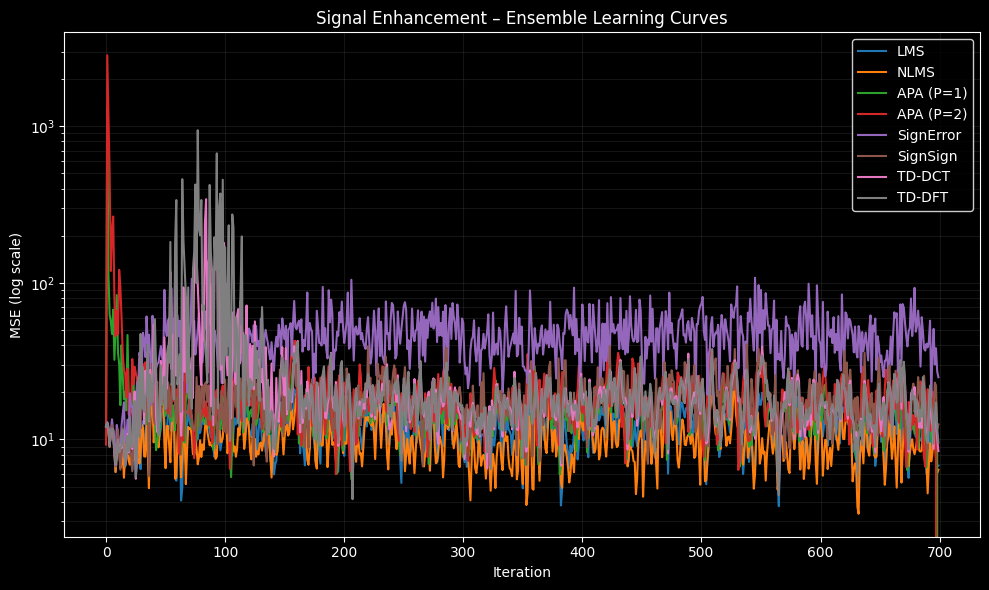

In [11]:

plt.figure(figsize=(10, 6))

for name, filt in filters.items():
    print(f"Running {name} ...")
    mse = runSigEnhanced(filt, n_samples, n_ensemble, h)
    plt.semilogy(mse, label=name)

plt.xlabel("Iteration")
plt.ylabel("MSE (log scale)")
plt.title("Signal Enhancement – Ensemble Learning Curves")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()